# Visualização da janela deslizante e sub-grids — Arapiraca

Gera uma figura (`subgrids_sequence_arapiraca.png`) com uma amostra do conjunto de treino para uso na seção *Preparação para treinamento* do TCC.

Cada amostra é uma sequência de $29$ passos consecutivos de $12$h sobre um sub-grid $16 \times 16$:
- Os $28$ primeiros frames (cinza) são a **entrada** do modelo (lookback de $14$ dias).
- O $29^{\text{o}}$ frame (vermelho) é o **alvo** a ser previsto.

**Entrada:** `./output/arapiraca/arapiraca_chrono.npz`

**Saída:** `./crime_deeping_learning/figuras/subgrids_sequence_arapiraca.png`

## 1. Configuração e carregamento

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

CITY = "arapiraca"
SEED = 42
N_INPUT_FRAMES = 28      # = seq_length - 1
GRID_SIZE_SUB = 16
MIN_TARGET_POSITIVES = 2  # selecionar amostra com ao menos 2 positivos no alvo, para clareza visual

FIG_DIR = Path("./crime_deeping_learning/figuras")
FIG_DIR.mkdir(parents=True, exist_ok=True)

data = np.load(f"./output/{CITY}/{CITY}_chrono.npz")
x_train = data["x_train"]  # (N, 28, 16, 16, 1)
y_train = data["y_train"]  # (N, 16, 16, 1)
i_train = data["i_train"]  # (N, 2)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"i_train shape: {i_train.shape}")

x_train shape: (27590, 28, 16, 16, 1)
y_train shape: (27590, 16, 16, 1)
i_train shape: (27590, 2)


## 2. Seleção aleatória de uma amostra com sinal claro no alvo

A semente `SEED` fixa a escolha para reprodutibilidade. Filtra amostras com pelo menos `MIN_TARGET_POSITIVES` ocorrências no alvo, para que o frame vermelho mostre algo distinguível (e não só uma única célula isolada).

In [2]:
rng = np.random.default_rng(SEED)

target_counts = np.array([int(np.nansum(y_train[k])) for k in range(len(y_train))])
candidates = np.where(target_counts >= MIN_TARGET_POSITIVES)[0]
sample_idx = int(rng.choice(candidates))

x_sample = x_train[sample_idx, :, :, :, 0]   # (28, 16, 16)
y_sample = y_train[sample_idx, :, :, 0]      # (16, 16)
i_top, j_top = i_train[sample_idx]

n_pos_in_input = int(np.nansum(x_sample))
n_pos_in_target = int(np.nansum(y_sample))

print(f"Amostra selecionada: idx = {sample_idx}")
print(f"Origem do sub-grid (top-left no grid {data['x_train'].shape[2]}x{data['x_train'].shape[3]}): ({i_top}, {j_top})")
print(f"Ocorrências no histórico (28 frames): {n_pos_in_input}")
print(f"Ocorrências no alvo (1 frame):        {n_pos_in_target}")

Amostra selecionada: idx = 2515


Origem do sub-grid (top-left no grid 16x16): (21, 15)
Ocorrências no histórico (28 frames): 40
Ocorrências no alvo (1 frame):        2


## 3. Plot da sequência

Layout: $5$ linhas $\times$ $6$ colunas. Os $28$ primeiros painéis são a entrada (em ordem cronológica de $t-28$ a $t-1$), o $29^{\text{o}}$ é o alvo (em vermelho). O último painel fica oculto.

Figura salva em: crime_deeping_learning/figuras/subgrids_sequence_arapiraca.png


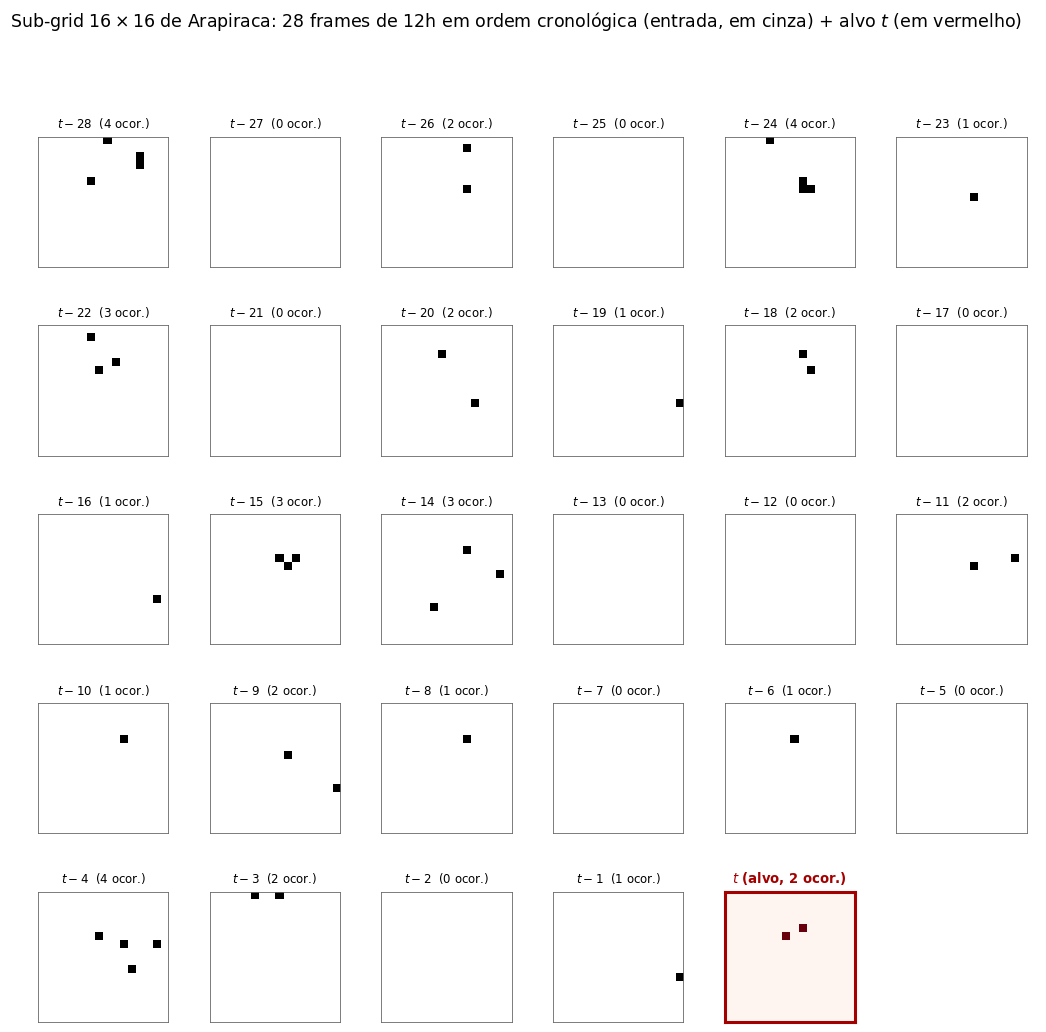

In [3]:
n_cols = 6
n_rows = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 11.5), gridspec_kw={"hspace": 0.45, "wspace": 0.15})
axes_flat = axes.flatten()

# Entrada: 28 frames
for k in range(N_INPUT_FRAMES):
    ax = axes_flat[k]
    frame = np.nan_to_num(x_sample[k], nan=0.0)
    ax.imshow(frame, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
    n_pos = int(frame.sum())
    ax.set_title(f"$t-{N_INPUT_FRAMES - k}$  ({n_pos} ocor.)", fontsize=8.5)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#666666")
        spine.set_linewidth(0.6)

# Alvo
ax = axes_flat[N_INPUT_FRAMES]
y_clean = np.nan_to_num(y_sample, nan=0.0)
ax.imshow(y_clean, cmap="Reds", vmin=0, vmax=1, interpolation="nearest")
ax.set_title(f"$t$ (alvo, {int(y_clean.sum())} ocor.)", fontsize=9.5, fontweight="bold", color="#a40000")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor("#a40000")
    spine.set_linewidth(2.2)

# Painel final vazio
axes_flat[N_INPUT_FRAMES + 1].axis("off")

fig.suptitle(
    f"Sub-grid $16 \\times 16$ de Arapiraca: $28$ frames de $12$h em ordem cronológica (entrada, em cinza) + alvo $t$ (em vermelho)",
    fontsize=12.5,
    y=0.99,
)

out_path = FIG_DIR / f"subgrids_sequence_{CITY}.png"
fig.savefig(out_path, dpi=140, bbox_inches="tight")
print(f"Figura salva em: {out_path}")
plt.show()